# Modelo

Para ver como cambia la performance del modelo con el tratamiento de los datos primero hay que tener un modelo de partida que optimizar.

In [1]:
import numpy as np
import pandas as pd
import os
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform, norm, loguniform

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV

from sklearn.preprocessing import FunctionTransformer
from transformers import Resampler, BandPassFilter, SpectralSubtractor, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor, WaveletDenoiser

from config import TEST_SIZE, SEED

## Espectrogramas

Se suelen usar Mel espectrogramas

Traigo los consjuntos de entrenamiento y testeo. (TODO: buscar una manera más eficiente de guardarlos)

In [6]:
train_data = np.load('./dataset/ciclos_train/train_melspectrogram.npz')
X_train = train_data['X']
y_train = train_data['y']

test_data = np.load('./dataset/ciclos_test/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

### Random Forest

#### Entrenamiento

In [3]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_distributions = {
    'max_depth': randint(8, 17),
    'min_samples_split': randint(10, 25),
    'min_samples_leaf': randint(10, 25)
}

el scoring podría ser recall 

In [4]:
rnd_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=10,
    scoring='recall',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    verbose=3,
    random_state=SEED
)

rnd_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END max_depth=14, min_samples_leaf=13, min_samples_split=22;, score=0.665 total time=   6.3s
[CV 2/5] END max_depth=14, min_samples_leaf=13, min_samples_split=22;, score=0.669 total time=   6.4s
[CV 3/5] END max_depth=14, min_samples_leaf=13, min_samples_split=22;, score=0.655 total time=  10.3s
[CV 4/5] END max_depth=14, min_samples_leaf=13, min_samples_split=22;, score=0.665 total time=  13.1s
[CV 5/5] END max_depth=14, min_samples_leaf=13, min_samples_split=22;, score=0.636 total time=  13.2s
[CV 1/5] END max_depth=15, min_samples_leaf=22, min_samples_split=14;, score=0.642 total time=  12.1s
[CV 2/5] END max_depth=15, min_samples_leaf=22, min_samples_split=14;, score=0.660 total time=  12.3s
[CV 3/5] END max_depth=15, min_samples_leaf=22, min_samples_split=14;, score=0.667 total time=  11.9s
[CV 4/5] END max_depth=15, min_samples_leaf=22, min_samples_split=14;, score=0.671 total time=   5.4s
[CV 5/5] END max_dept

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....0022102640050>, 'min_samples_leaf': <scipy.stats....0022102537ED0>, 'min_samples_split': <scipy.stats....0022102537C50>}"
,n_iter,10
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [5]:
pd.DataFrame(rnd_search.cv_results_)[['param_max_depth', 'param_min_samples_leaf', 'param_min_samples_split', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False)

,param_max_depth,param_min_samples_leaf,param_min_samples_split,mean_test_score
9,12,10,21,0.667311
8,13,11,21,0.666537
6,13,14,11,0.663830
4,15,14,13,0.660735
0,14,13,22,0.658010
2,14,19,12,0.657637
3,14,20,20,0.656464
1,15,22,14,0.653371
5,15,17,12,0.651827
7,15,21,23,0.650268


In [6]:
print("Best params:", rnd_search.best_params_)
print("Best CV score:", rnd_search.best_score_)

best_model = rnd_search.best_estimator_

Best params: {'max_depth': 12, 'min_samples_leaf': 10, 'min_samples_split': 21}
Best CV score: 0.667311411992263


In [7]:
y_pred = best_model.predict(X_train)
print(classification_report(y_train, y_pred))
print('AUC-ROC: ', round(roc_auc_score(y_train, y_pred), 2))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      2841
           1       0.90      0.91      0.91      2582

    accuracy                           0.91      5423
   macro avg       0.91      0.91      0.91      5423
weighted avg       0.91      0.91      0.91      5423

AUC-ROC:  0.91


#### Evaluación

In [ ]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))
print('AUC-ROC: ', round(roc_auc_score(y_test, y_pred), 2))

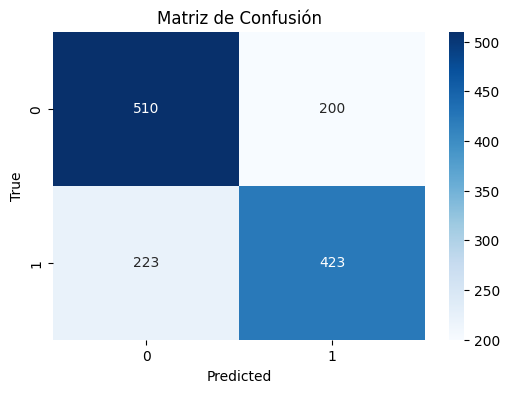

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de Confusión');

#### Guardado

In [10]:
df_paths = pd.read_csv('./dataset/ciclos_train/train_filenames.csv')
paths = ['./dataset/ciclos/' + f for f in df_paths['cycle_wav_file']]
y_train = df_paths['label'].values

In [11]:
# pipeline con la que se creo el dataset
pipeline_melspec = Pipeline([
    ('resampler', Resampler()),
    ('bandpass', BandPassFilter()),
    ('melspec', MelSpectrogramTransformer()),
    ('pad', SpectrogramPadder()),
    ('flatten', FlattenTransformer()),
    # modelo
    ('rf', best_model)
])

pipeline_melspec.fit(paths, y_train)

,steps,"[('resampler', ...), ('bandpass', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sr_target,16000
,lowcut,100
,highcut,4000
,order,6
,sr,16000
,sr,16000
,n_mels,128


Guardo el modelo

In [ ]:
joblib.dump(pipeline_melspec, './modelos/melspec_bp100_4000_rf.pkl')

['./modelos/melspec_bp100_4000_wd_rf.pkl']

#### Evaluación en audios propios

Tengo grabaciones que fueron divididas en ciclos con el segmentador. El audio "respiración4_ciclo5" tiene una sibilancia clara, los demás ciclos de ese audio podrían ser positivos también pero no logro escuchar una sibilancia tan clara.

In [2]:
model = joblib.load('./modelos/melspec_bp100_4000_rf.pkl')

In [3]:
path = './audios_propios/ciclos_energy_based'
files = os.listdir(path)

df_audios_propios = pd.DataFrame(files, columns=['cycle_wav_file'])

df_audios_propios['label'] = np.where(df_audios_propios['cycle_wav_file'].str.contains('respiracion4'), 1, 0)

df_audios_propios # audios de validacion

,cycle_wav_file,label
0,respiracion1_ciclo_1.wav,0
1,respiracion1_ciclo_2.wav,0
2,respiracion1_ciclo_3.wav,0
3,respiracion1_ciclo_4.wav,0
4,respiracion1_ciclo_5.wav,0
5,respiracion1_ciclo_6.wav,0
6,respiracion1_ciclo_7.wav,0
7,respiracion2_ciclo_1.wav,0
8,respiracion2_ciclo_2.wav,0
9,respiracion2_ciclo_3.wav,0


In [4]:
archivos = df_audios_propios['cycle_wav_file'].tolist()

X_propios_paths = [os.path.join(path, f) for f in archivos]
y_propios = df_audios_propios['label'].values

Predecimos

In [28]:
y_propios_pred = model.predict(X_propios_paths)
y_propios_proba_pred = model.predict_proba(X_propios_paths)[:, 1]

In [29]:
print(classification_report(y_propios, y_propios_pred))

              precision    recall  f1-score   support

           0       0.93      0.60      0.72        42
           1       0.23      0.71      0.34         7

    accuracy                           0.61        49
   macro avg       0.58      0.65      0.53        49
weighted avg       0.83      0.61      0.67        49



In [30]:
df_audios_propios['predicted'] = y_propios_pred
df_audios_propios['probability'] = y_propios_proba_pred.round(2)
df_audios_propios

,cycle_wav_file,label,predicted,probability
0,respiracion1_ciclo_1.wav,0,1,0.54
1,respiracion1_ciclo_2.wav,0,0,0.24
2,respiracion1_ciclo_3.wav,0,1,0.52
3,respiracion1_ciclo_4.wav,0,0,0.16
4,respiracion1_ciclo_5.wav,0,1,0.55
5,respiracion1_ciclo_6.wav,0,0,0.46
6,respiracion1_ciclo_7.wav,0,1,0.60
7,respiracion2_ciclo_1.wav,0,1,0.50
8,respiracion2_ciclo_2.wav,0,1,0.51
9,respiracion2_ciclo_3.wav,0,1,0.57


Parece prometedor, varios ciclos del audio 4 fueron clasificados como anormales.

## Atributos de Audio

1. Resample y Filtro pasa bajos
2. Feature Extractor
    + MFCC
    + ZCR
    + Short-Time Energy
    + SC
    + Spectral Roll-off
    + BER
    + Spectral Flatness
3. Scaler

In [21]:
train_df = pd.read_csv('./dataset/ciclos_train/train_features.csv')
test_df = pd.read_csv('./dataset/ciclos_test/test_features.csv')

X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

### Random Forest

#### Entrenamiento

In [22]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_distributions = {
    'max_depth': randint(5, 15),
    'min_samples_split': randint(10, 25),
    'min_samples_leaf': randint(10, 25)
}

In [24]:
rnd_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='recall',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    verbose=3,
    random_state=SEED
)

rnd_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END max_depth=11, min_samples_leaf=13, min_samples_split=22;, score=0.658 total time=   0.3s
[CV 2/5] END max_depth=11, min_samples_leaf=13, min_samples_split=22;, score=0.706 total time=   0.3s
[CV 3/5] END max_depth=11, min_samples_leaf=13, min_samples_split=22;, score=0.667 total time=   0.2s
[CV 4/5] END max_depth=11, min_samples_leaf=13, min_samples_split=22;, score=0.669 total time=   0.3s
[CV 5/5] END max_depth=11, min_samples_leaf=13, min_samples_split=22;, score=0.657 total time=   0.2s
[CV 1/5] END max_depth=12, min_samples_leaf=22, min_samples_split=14;, score=0.636 total time=   0.2s
[CV 2/5] END max_depth=12, min_samples_leaf=22, min_samples_split=14;, score=0.692 total time=   0.3s
[CV 3/5] END max_depth=12, min_samples_leaf=22, min_samples_split=14;, score=0.659 total time=   0.2s
[CV 4/5] END max_depth=12, min_samples_leaf=22, min_samples_split=14;, score=0.649 total time=   0.2s
[CV 5/5] END max_dep

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....00221E53488A0>, 'min_samples_leaf': <scipy.stats....00221E5296450>, 'min_samples_split': <scipy.stats....00221E53489D0>}"
,n_iter,20
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [25]:
pd.DataFrame(rnd_search.cv_results_)[['param_max_depth', 'param_min_samples_leaf', 'param_min_samples_split', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False)

,param_max_depth,param_min_samples_leaf,param_min_samples_split,mean_test_score
11,13,10,20,0.690157
15,9,12,16,0.682796
8,10,11,21,0.680087
4,12,14,13,0.677375
9,9,10,21,0.676989
6,10,14,11,0.675437
19,14,14,11,0.673503
0,11,13,22,0.671177
10,14,15,22,0.671176
5,12,17,12,0.666534


In [26]:
print("Best params:", rnd_search.best_params_)
print("Best CV score:", rnd_search.best_score_)

best_model = rnd_search.best_estimator_

Best params: {'max_depth': 13, 'min_samples_leaf': 10, 'min_samples_split': 20}
Best CV score: 0.6901571379305174


In [27]:
y_pred = best_model.predict(X_train)
print(classification_report(y_train, y_pred))
print('AUC-ROC: ', round(roc_auc_score(y_train, y_pred), 2))
print('Recall: ', round(recall_score(y_train, y_pred), 2))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      2841
           1       0.89      0.85      0.87      2582

    accuracy                           0.88      5423
   macro avg       0.88      0.88      0.88      5423
weighted avg       0.88      0.88      0.88      5423

AUC-ROC:  0.88
Recall:  0.85


#### Evaluación

In [39]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))
print('AUC-ROC: ', round(roc_auc_score(y_test, y_pred), 2))

              precision    recall  f1-score   support

           0       0.73      0.78      0.76       710
           1       0.74      0.69      0.71       646

    accuracy                           0.74      1356
   macro avg       0.74      0.73      0.73      1356
weighted avg       0.74      0.74      0.73      1356

AUC-ROC:  0.73


c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


#### Guardado

In [29]:
df_paths = pd.read_csv('./dataset/ciclos_train/train_filenames.csv')
paths = ['./dataset/ciclos/' + f for f in df_paths['cycle_wav_file']]
y_train = df_paths['label'].values

In [30]:
# pipeline con la que se creo el dataset, TODO: se pueden agregar transformaciones para audios de celulares
pipeline_feature_extraction = Pipeline([
    ('resampler', Resampler()),
    ('wavelet_denoiser', WaveletDenoiser()),
    ('bandpass', BandPassFilter()),
    ('feature_extractor', FeatureExtractor()),
    ('rf', best_model)
])

pipeline_feature_extraction.fit(paths, y_train)

,steps,"[('resampler', ...), ('wavelet_denoiser', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sr_target,16000
,wavelet,'db4'
,level,4
,threshold_method,'soft'
,lowcut,100
,highcut,4000
,order,6


Guardo el modelo

In [31]:
joblib.dump(pipeline_feature_extraction, './modelos/features_bp100_4000_wd_rf.pkl')

['./modelos/features_bp100_4000_wd_rf.pkl']

#### Validación

In [32]:
modelo = joblib.load('./modelos/features_bp100_4000_wd_rf.pkl')

In [33]:
y_propios_pred = modelo.predict(X_propios_paths)
y_propios_proba_pred = modelo.predict_proba(X_propios_paths)[:, 1]

In [34]:
print(classification_report(y_propios, y_propios_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93        42
           1       1.00      0.14      0.25         7

    accuracy                           0.88        49
   macro avg       0.94      0.57      0.59        49
weighted avg       0.89      0.88      0.84        49



In [35]:
df_audios_propios['predicted'] = y_propios_pred
df_audios_propios['probability'] = y_propios_proba_pred.round(2)
df_audios_propios

,cycle_wav_file,label,predicted,probability
0,respiracion1_ciclo_1.wav,0,0,0.27
1,respiracion1_ciclo_2.wav,0,0,0.26
2,respiracion1_ciclo_3.wav,0,0,0.25
3,respiracion1_ciclo_4.wav,0,0,0.27
4,respiracion1_ciclo_5.wav,0,0,0.24
5,respiracion1_ciclo_6.wav,0,0,0.28
6,respiracion1_ciclo_7.wav,0,0,0.23
7,respiracion2_ciclo_1.wav,0,0,0.26
8,respiracion2_ciclo_2.wav,0,0,0.25
9,respiracion2_ciclo_3.wav,0,0,0.22


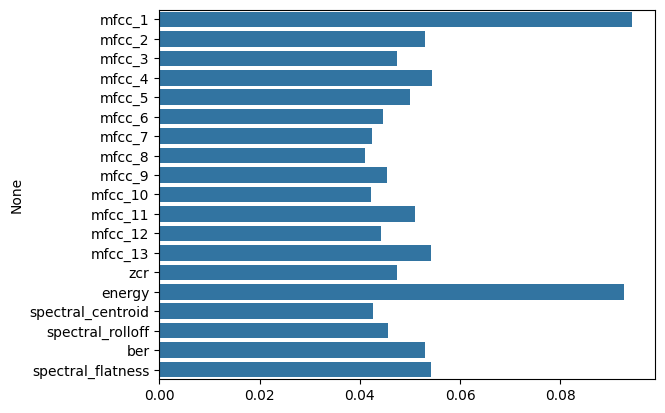

In [ ]:
sns.barplot(x=best_model.feature_importances_, y=X_train.columns);